1. UNSUPERVISED LEARNING :
    it is a process of giving unlabelled data to the machine and predicting groups or patterns from the data.
2. Clustering:
    grouping of similar objects or elements
    Types:
        1. Centroid based cluster - Kmeans 
        2. Tress based cluster(Hierarchial)  - Agglomerative
        3. Density based cluster - DBSCAN , GMM

3. Centroid based cluster 
    KMEANS - groups data points into k clusters such that point in the same cluster are as similar as possible.
    Working :
        1. Choose k value
        2. Place k random centroids which are temporary
        3. Assign points to nearest centroids
        4. Recalculate centroid i.e, mean value
        5. Repeat step 3 and 4 and untill centroid point stops moving.
    --> scaling is mandotary 
    --> it is outlier sensitive
    --> Inertia - it is a evaluation technique where it tells how good or the quality of the cluster.
    it is the total distance of all points from their respective cluster centres and tells how compact the clusters are
    no.of clusters increase the inertia value decrease.
    but inertia alone is not enough to say whether a cluster is good or bad.
    so we use,
    --> Silhouette Score - measures how similar a datapoint to its own cluster compared to other clusters.
    



In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('D:\Python\TekWorks\Week_11\Instagram visits clustering.csv')
df.head()

,User ID,Instagram visit score,Spending_rank(0 to 100)
0,0,63,24.050708
1,1,61,25.223290
2,2,104,18.528245
3,3,82,86.890232
4,4,14,31.492397


In [5]:
df.drop('User ID',axis=1,inplace=True)

In [6]:
df.isna().sum()

Instagram visit score      0
Spending_rank(0 to 100)    0
dtype: int64

<Axes: >

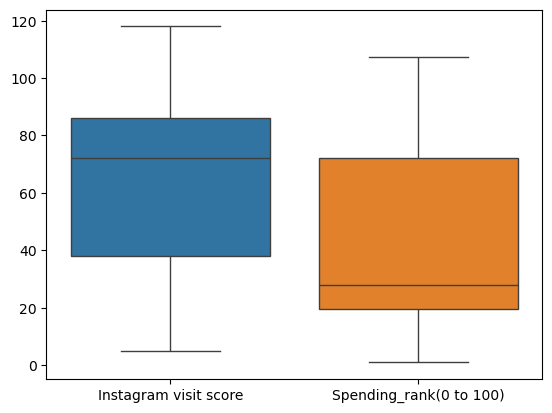

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(df)

In [29]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit_transform(df[['Instagram visit score']],df[['Spending_rank(0 to 100)']])


array([[-0.01217181],
       [-0.08743151],
       [ 1.53065202],
       ...,
       [ 1.38013262],
       [ 0.89094458],
       [-1.10343744]])

<Axes: xlabel='Instagram visit score', ylabel='Spending_rank(0 to 100)'>

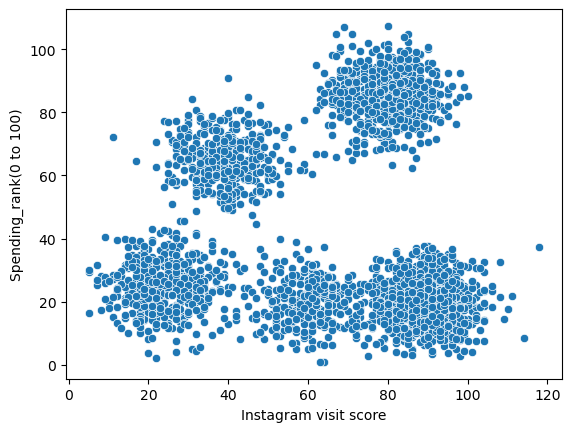

In [30]:
sns.scatterplot(
    x="Instagram visit score", y="Spending_rank(0 to 100)", data=df
)

In [60]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=4)
km.fit(df)

KMeans(n_clusters=4)

In [61]:
from sklearn.metrics import silhouette_score
silhouette_score(df,km.labels_)*100

np.float64(64.5251085407743)

<Axes: xlabel='Instagram visit score', ylabel='Spending_rank(0 to 100)'>

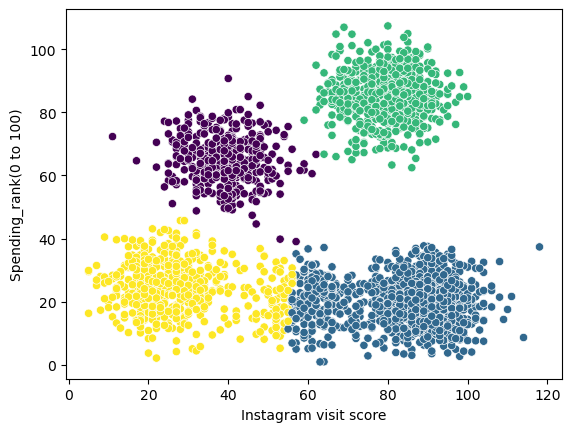

In [70]:
sns.scatterplot(
    x="Instagram visit score", y="Spending_rank(0 to 100)",c=km.labels_,data=df
)



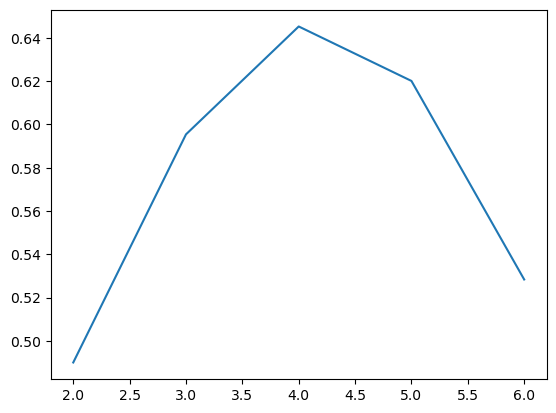

In [52]:
#Elbow Method
sil = []
for k in range(2,7):
    model = KMeans(n_clusters=k)
    model.fit(df)
    sil.append(silhouette_score(df,model.labels_))
c = [2,3,4,5,6]
plt.plot(c,sil)
